# Iris Classification — Full ML Pipeline

**Dataset**: 150 samples · 4 numeric features · 3 species classes (50 each).

| Section | Topic |
|---|---|
| 1 | Data Loading & Exploration |
| 2 | Exploratory Data Analysis |
| 3 | Preprocessing (encode → split → scale) |
| 4 | First model: Gaussian Naive Bayes (naive baseline) |
| 5 | Cross-validation with Pipeline |
| 6 | Evaluation deep dive |
| 7 | Multi-model comparison |
| 8 | Hyperparameter tuning + final test evaluation |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)
print('Imports OK')

Imports OK


---
## 1. Data Loading & Initial Exploration

Always inspect raw data first: shape, types, missing values, class balance.

In [2]:
df = pd.read_csv('Iris.csv')
print(f'Shape: {df.shape}  ({df.shape[0]} samples, {df.shape[1]} columns)')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (150, 6)  (150 samples, 6 columns)
Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()
print()
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00,150.00
mean,75.50,5.84,3.05,3.76,1.20
std,43.45,0.83,0.43,1.76,0.76
min,1.00,4.30,2.00,1.00,0.10
25%,38.25,5.10,2.80,1.60,0.30
50%,75.50,5.80,3.00,4.35,1.30
75%,112.75,6.40,3.30,5.10,1.80
max,150.00,7.90,4.40,6.90,2.50


Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


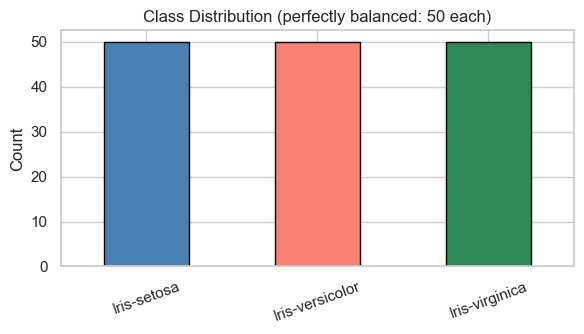

In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Class distribution:')
print(df['Species'].value_counts())

fig, ax = plt.subplots(figsize=(6, 3.5))
df['Species'].value_counts().plot(
    kind='bar', color=['steelblue', 'salmon', 'seagreen'],
    edgecolor='black', ax=ax
)
ax.set(title='Class Distribution (perfectly balanced: 50 each)',
       xlabel='', ylabel='Count')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

---
## 2. Exploratory Data Analysis (EDA)

Goal: understand which features separate the classes and how they relate to each other.

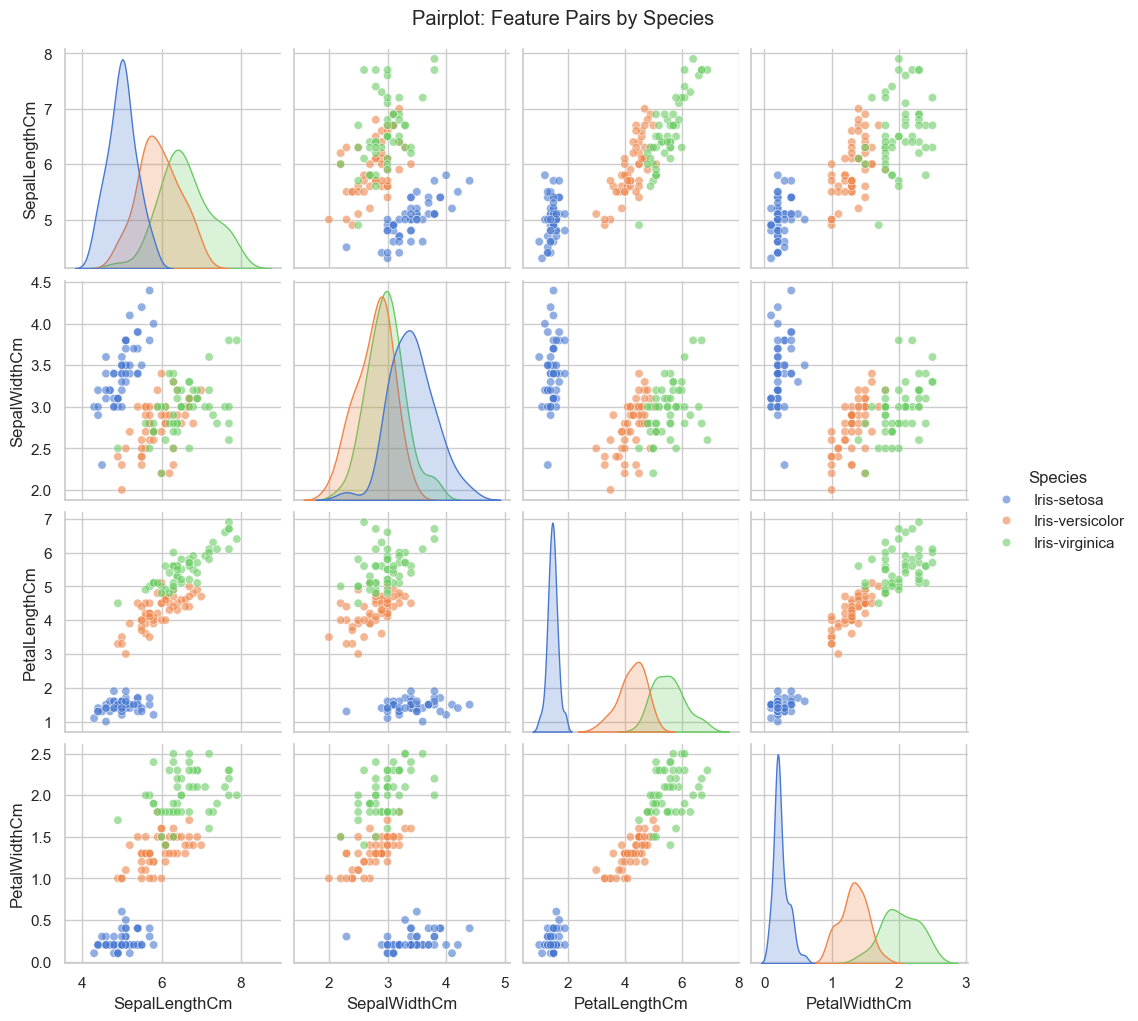

In [5]:
# All feature pairs colored by species
# Key insight: petal features separate species much more cleanly than sepal features
g = sns.pairplot(
    df.drop('Id', axis=1),
    hue='Species',
    diag_kind='kde',
    plot_kws={'alpha': 0.6},
)
g.fig.suptitle('Pairplot: Feature Pairs by Species', y=1.02)
plt.show()

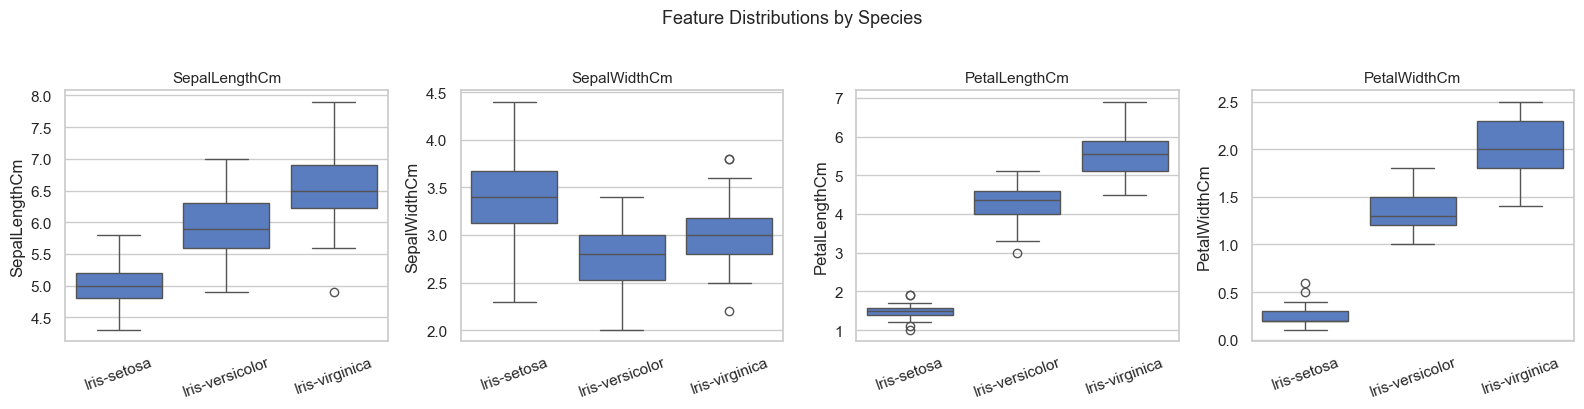

In [6]:
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, features):
    sns.boxplot(x='Species', y=feat, data=df, ax=ax)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Feature Distributions by Species', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

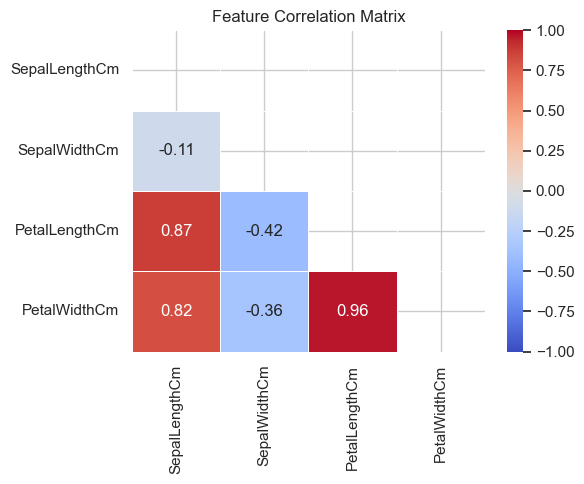

PetalLength & PetalWidth are highly correlated (r~0.96) — nearly redundant


In [7]:
num_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()
print('PetalLength & PetalWidth are highly correlated (r~0.96) — nearly redundant')

---
## 3. Preprocessing

Three steps in strict order:
1. **Encode** string labels to integers (required by sklearn classifiers)
2. **Split** into train / val / test with `stratify` to preserve class ratios in each split
3. **Scale** features — always fit the scaler on train only to prevent data leakage

In [8]:
df = df.drop('Id', axis=1)

le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

print('Label encoding map:')
for i, name in enumerate(le.classes_):
    print(f'  {i}  ->  {name}')
print()
print('Reverse with: le.inverse_transform([0, 1, 2]) =', le.inverse_transform([0, 1, 2]))
print()
df.sample(5, random_state=1)

Label encoding map:
  0  ->  Iris-setosa
  1  ->  Iris-versicolor
  2  ->  Iris-virginica

Reverse with: le.inverse_transform([0, 1, 2]) = ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']



,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
14,5.8,4.0,1.2,0.2,0
98,5.1,2.5,3.0,1.1,1
75,6.6,3.0,4.4,1.4,1
16,5.4,3.9,1.3,0.4,0
131,7.9,3.8,6.4,2.0,2


In [9]:
X = df.drop('Species', axis=1)
y = df['Species']

# 60% train / 20% val / 20% test — two-step split
# stratify=y preserves class ratio in each split
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42
)

print(f'Train: {len(X_train):3d} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val:   {len(X_val):3d} ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test:  {len(X_test):3d} ({len(X_test)/len(X)*100:.0f}%)')
print()
print('Class counts per split (should be balanced — stratify worked):')
for sname, y_s in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'  {sname}: {dict(pd.Series(y_s.values).value_counts().sort_index())}')

Train:  90 (60%)
Val:    30 (20%)
Test:   30 (20%)

Class counts per split (should be balanced — stratify worked):
  Train: {0: np.int64(30), 1: np.int64(30), 2: np.int64(30)}
  Val: {0: np.int64(10), 1: np.int64(10), 2: np.int64(10)}
  Test: {0: np.int64(10), 1: np.int64(10), 2: np.int64(10)}


In [10]:
scaler = StandardScaler()

# fit_transform on train: learns mean & std FROM training data, then scales it
X_train_sc = scaler.fit_transform(X_train)
# transform ONLY on val/test: applies the same mean/std — no new fitting
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Scaler learned from training set:')
for feat, mean, std in zip(X.columns, scaler.mean_, scaler.scale_):
    print(f'  {feat:<18}  mean={mean:.3f}  std={std:.3f}')
print()
print('After scaling, train column means (should be ~0):')
print(X_train_sc.mean(axis=0).round(5))
print('After scaling, train column stds (should be ~1):')
print(X_train_sc.std(axis=0).round(5))

Scaler learned from training set:
  SepalLengthCm       mean=5.868  std=0.857
  SepalWidthCm        mean=3.059  std=0.464
  PetalLengthCm       mean=3.794  std=1.771
  PetalWidthCm        mean=1.202  std=0.771

After scaling, train column means (should be ~0):
[-0. -0.  0. -0.]
After scaling, train column stds (should be ~1):
[1. 1. 1. 1.]


---
## 4. First Model — Gaussian Naive Bayes (Naive Baseline)

Start with the simplest model to establish a baseline. GNB assumes:
- Features are **conditionally independent** given the class (the "naive" assumption)
- Each feature follows a **Gaussian distribution** within each class

Both assumptions are often violated, yet GNB frequently works well in practice and trains instantly.
Always get a baseline before adding complexity.

In [11]:
gnb = GaussianNB()
gnb.fit(X_train_sc, y_train)

y_pred_val  = gnb.predict(X_val_sc)
y_pred_test = gnb.predict(X_test_sc)

# predict_proba: class probabilities — needed for ROC curves, confidence thresholds
y_prob_val  = gnb.predict_proba(X_val_sc)   # shape: (n_samples, n_classes)
y_prob_test = gnb.predict_proba(X_test_sc)

print('First 5 validation predictions vs true labels:')
pred_df = pd.DataFrame({
    'True':      y_val.values[:5],
    'Predicted': y_pred_val[:5],
    'Correct':   y_val.values[:5] == y_pred_val[:5],
})
display(pred_df)
print()
print('Predicted probabilities for first 3 val samples:')
display(pd.DataFrame(y_prob_val[:3], columns=le.classes_).round(3))

First 5 validation predictions vs true labels:


,True,Predicted,Correct
0,2,2,True
1,0,0,True
2,2,2,True
3,1,1,True
4,1,1,True



Predicted probabilities for first 3 val samples:


,Iris-setosa,Iris-versicolor,Iris-virginica
0,0.0,0.103,0.897
1,1.0,0.000,0.000
2,0.0,0.001,0.999


In [12]:
val_acc = accuracy_score(y_val, y_pred_val)
print(f'Validation accuracy: {val_acc:.3f}  ({int(val_acc * len(y_val))}/{len(y_val)} correct)')
print()
print('Confusion matrix (rows = true label, cols = predicted label):')
cm = confusion_matrix(y_val, y_pred_val)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
cm_df.index.name = 'True / Pred'
display(cm_df)

Validation accuracy: 0.933  (28/30 correct)

Confusion matrix (rows = true label, cols = predicted label):


,Iris-setosa,Iris-versicolor,Iris-virginica
True / Pred,,,
Iris-setosa,10,0,0
Iris-versicolor,0,9,1
Iris-virginica,0,1,9


---
## 5. Cross-Validation with Pipeline

**Why CV?** A single val split gives a noisy estimate — different random seeds give different scores.
K-fold CV trains and scores *k* times on different data subsets for a reliable mean ± std.

**Why Pipeline?** Inside each fold, the scaler must be fit only on that fold's training portion.
Pipeline automates this correctly: `fit_transform` on fold-train, `transform` on fold-val. No leakage.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline chains preprocessing + model into one estimator
pipe_gnb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    GaussianNB()),
])

cv_scores = cross_val_score(pipe_gnb, X_train, y_train, cv=cv, scoring='accuracy')

print('CV accuracy per fold:', cv_scores.round(3))
print(f'Mean: {cv_scores.mean():.3f}')
print(f'Std:  {cv_scores.std():.3f}')
print(f'95% CI: ({cv_scores.mean() - 2*cv_scores.std():.3f}, {cv_scores.mean() + 2*cv_scores.std():.3f})')
print()
print(f'Single val split was {val_acc:.3f}  <- CV gives a more stable estimate')

CV accuracy per fold: [1.    0.944 1.    0.944 0.889]
Mean: 0.956
Std:  0.042
95% CI: (0.872, 1.039)

Single val split was 0.933  <- CV gives a more stable estimate


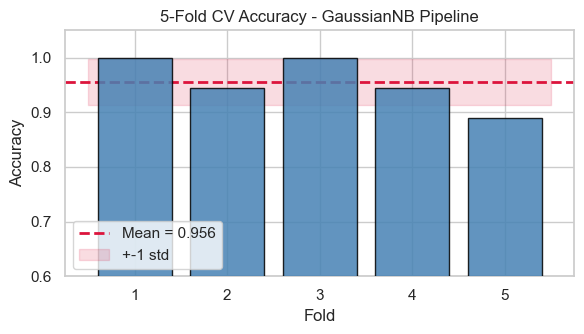

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(range(1, len(cv_scores)+1), cv_scores,
       color='steelblue', edgecolor='black', alpha=0.85, zorder=3)
ax.axhline(cv_scores.mean(), color='crimson', linestyle='--', lw=2,
           label=f'Mean = {cv_scores.mean():.3f}')
ax.fill_between([0.5, len(cv_scores)+0.5],
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color='crimson', label='+-1 std')
ax.set(xlabel='Fold', ylabel='Accuracy', ylim=(0.6, 1.05),
       title='5-Fold CV Accuracy - GaussianNB Pipeline')
ax.set_xticks(range(1, len(cv_scores)+1))
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Evaluation Deep Dive

Accuracy is one number — it hides a lot. Use:
- **Confusion matrix** — which specific classes get confused with which
- **Precision / Recall / F1** — per-class breakdown (crucial for imbalanced datasets)
- **ROC curves & AUC** — discrimination ability across all probability thresholds

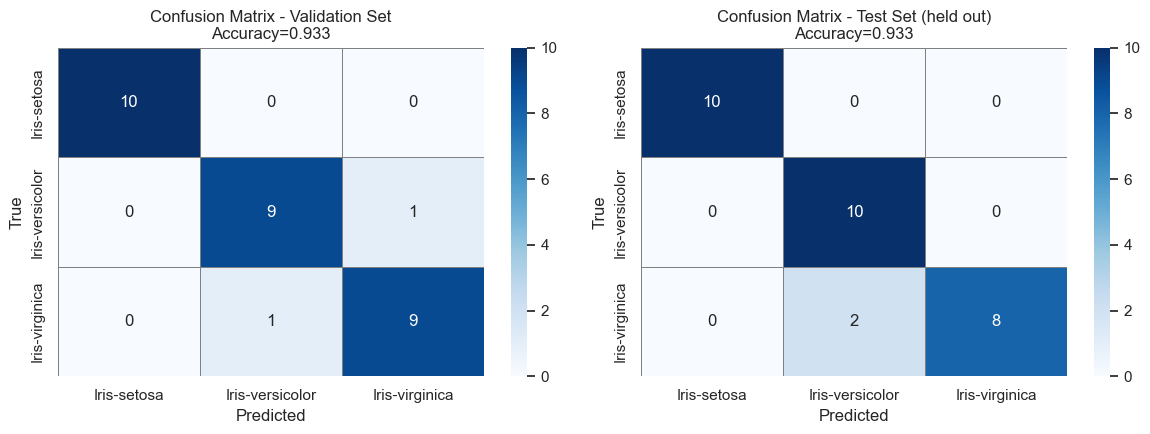

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (y_true, y_pred, title) in zip(axes, [
    (y_val,  y_pred_val,  'Validation Set'),
    (y_test, y_pred_test, 'Test Set (held out)'),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, linecolor='gray', ax=ax)
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'Confusion Matrix - {title}\nAccuracy={acc:.3f}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()

In [16]:
print('=== Classification Report - Test Set ===')
print(classification_report(y_test, y_pred_test, target_names=le.classes_))
print()
print('Precision: of everything predicted as class X, how many truly are X?')
print('Recall:    of all true class X samples, how many did we catch?')
print('F1:        harmonic mean of precision & recall')
print('Support:   number of true instances of that class in this split')

=== Classification Report - Test Set ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30


Precision: of everything predicted as class X, how many truly are X?
Recall:    of all true class X samples, how many did we catch?
F1:        harmonic mean of precision & recall
Support:   number of true instances of that class in this split


### Precision, Recall & F1 — Formula Breakdown

For each class, treat it as the **positive** class (one-vs-rest):

|                    | Predicted Positive | Predicted Negative |
|--------------------|-------------------|-------------------|
| **Actually Positive** | TP                | FN                |
| **Actually Negative** | FP                | TN                |

- **Precision** = TP / (TP + FP) — *"When the model predicts class X, how often is it right?"*
- **Recall**    = TP / (TP + FN) — *"Of all true class X samples, what fraction did the model catch?"*
- **F1**        = 2 · P · R / (P + R) — harmonic mean; penalizes extreme imbalance between P and R more than the arithmetic mean

**When to prefer which:**
- High **precision**: Use when false positives are costly (e.g., spam filter mislabeling a legitimate email)
- High **recall**:    Use when false negatives are costly (e.g., cancer screening missing a true case)
- **F1**:             Use when you need a balance between precision and recall

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('=== sklearn — Per-Class Precision, Recall, F1 (Test Set) ===')

# average=None returns one score per class in label order
prec_per = precision_score(y_test, y_pred_test, average=None)
rec_per  = recall_score(y_test,    y_pred_test, average=None)
f1_per   = f1_score(y_test,        y_pred_test, average=None)

display(pd.DataFrame({
    'Precision': prec_per,
    'Recall':    rec_per,
    'F1':        f1_per,
}, index=le.classes_).round(3))

print()
print('--- Aggregate scores (different averaging strategies) ---')
for avg in ['macro', 'weighted', 'micro']:
    p = precision_score(y_test, y_pred_test, average=avg)
    r = recall_score(y_test,    y_pred_test, average=avg)
    f = f1_score(y_test,        y_pred_test, average=avg)
    print(f'{avg:<10}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}')

print()
print('macro:    simple mean across classes — treats all classes equally')
print('weighted: mean weighted by support (# true instances) — fair under imbalance')
print('micro:    pool TP/FP/FN across all classes then divide — equals accuracy when balanced')

=== sklearn — Per-Class Precision, Recall, F1 (Test Set) ===


,Precision,Recall,F1
Iris-setosa,1.000,1.0,1.000
Iris-versicolor,0.833,1.0,0.909
Iris-virginica,1.000,0.8,0.889



--- Aggregate scores (different averaging strategies) ---
macro       Precision=0.944  Recall=0.933  F1=0.933
weighted    Precision=0.944  Recall=0.933  F1=0.933
micro       Precision=0.933  Recall=0.933  F1=0.933

macro:    simple mean across classes — treats all classes equally
weighted: mean weighted by support (# true instances) — fair under imbalance
micro:    pool TP/FP/FN across all classes then divide — equals accuracy when balanced


In [18]:
# --- Manual implementations ---
# For each class we treat it as the positive class (one-vs-rest)

def manual_precision(y_true, y_pred, cls):
    """TP / (TP + FP) — of everything predicted as cls, how many truly are cls?"""
    tp = np.sum((y_pred == cls) & (y_true == cls))
    fp = np.sum((y_pred == cls) & (y_true != cls))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def manual_recall(y_true, y_pred, cls):
    """TP / (TP + FN) — of all true cls instances, how many did we catch?"""
    tp = np.sum((y_pred == cls) & (y_true == cls))
    fn = np.sum((y_pred != cls) & (y_true == cls))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def manual_f1(y_true, y_pred, cls):
    """2 * P * R / (P + R) — harmonic mean of precision and recall"""
    p = manual_precision(y_true, y_pred, cls)
    r = manual_recall(y_true, y_pred, cls)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

yt_np = y_test.values
yp_np = y_pred_test

print('=== Manual Implementations (Test Set, one-vs-rest per class) ===')
rows = []
for i, name in enumerate(le.classes_):
    p = manual_precision(yt_np, yp_np, i)
    r = manual_recall(yt_np, yp_np, i)
    f = manual_f1(yt_np, yp_np, i)
    support = int(np.sum(yt_np == i))
    rows.append({'Class': name, 'TP': int(np.sum((yp_np==i)&(yt_np==i))),
                 'FP': int(np.sum((yp_np==i)&(yt_np!=i))),
                 'FN': int(np.sum((yp_np!=i)&(yt_np==i))),
                 'Precision': p, 'Recall': r, 'F1': f, 'Support': support})

display(pd.DataFrame(rows).set_index('Class').round(3))

# Macro average (simple mean across classes)
macro_p = np.mean([manual_precision(yt_np, yp_np, i) for i in range(len(le.classes_))])
macro_r = np.mean([manual_recall(yt_np, yp_np, i)    for i in range(len(le.classes_))])
macro_f = np.mean([manual_f1(yt_np, yp_np, i)        for i in range(len(le.classes_))])
print(f'\nMacro avg  Precision={macro_p:.3f}  Recall={macro_r:.3f}  F1={macro_f:.3f}')
print('(should match the sklearn macro avg below)')

=== Manual Implementations (Test Set, one-vs-rest per class) ===


,TP,FP,FN,Precision,Recall,F1,Support
Class,,,,,,,
Iris-setosa,10,0,0,1.000,1.0,1.000,10
Iris-versicolor,10,2,0,0.833,1.0,0.909,10
Iris-virginica,8,0,2,1.000,0.8,0.889,10



Macro avg  Precision=0.944  Recall=0.933  F1=0.933
(should match the sklearn macro avg below)


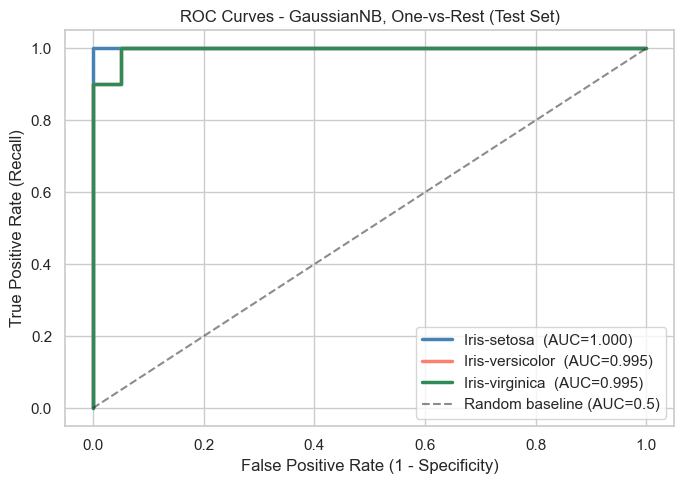

AUC=1.0 -> perfect.  AUC=0.5 -> no better than random guessing.


In [19]:
# Multi-class ROC: One-vs-Rest (OvR) — treat each class as a separate binary problem
# label_binarize converts [0,1,2] -> [[1,0,0],[0,1,0],[0,0,1]]
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # shape (n_test, 3)
colors = ['steelblue', 'salmon', 'seagreen']

fig, ax = plt.subplots(figsize=(7, 5))
for i, (cls_name, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_test[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{cls_name}  (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random baseline (AUC=0.5)')
ax.set(xlabel='False Positive Rate (1 - Specificity)',
       ylabel='True Positive Rate (Recall)',
       title='ROC Curves - GaussianNB, One-vs-Rest (Test Set)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
print('AUC=1.0 -> perfect.  AUC=0.5 -> no better than random guessing.')

---
## 7. Multi-Model Comparison

Run the **same pipeline** (StandardScaler + classifier) for several models. This ensures fair comparison:
- Identical preprocessing in every CV fold
- Swapping the classifier is a one-line change

Use 5-fold CV on train to rank models. **Do not touch the test set during model selection.**

In [20]:
model_zoo = {
    'GaussianNB':         GaussianNB(),
    'LogisticRegression': LogisticRegression(max_iter=500, random_state=42),
    'KNN (k=5)':          KNeighborsClassifier(n_neighbors=5),
    'DecisionTree':       DecisionTreeClassifier(random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':          SVC(kernel='rbf', probability=True, random_state=42),
}
print(f'{len(model_zoo)} models to compare:')
for name in model_zoo:
    print(f'  {name}')

7 models to compare:
  GaussianNB
  LogisticRegression
  KNN (k=5)
  DecisionTree
  RandomForest
  GradientBoosting
  SVM (RBF)


In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, clf in model_zoo.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    pipe.fit(X_train, y_train)
    # Use unscaled X_val — the pipeline handles scaling internally
    val_acc_i = accuracy_score(y_val, pipe.predict(X_val))
    results.append({
        'Model':   name,
        'CV Mean': scores.mean(),
        'CV Std':  scores.std(),
        'Val Acc': val_acc_i,
    })
    print(f'{name:<22}  CV={scores.mean():.3f}+-{scores.std():.3f}   Val={val_acc_i:.3f}')

results_df = pd.DataFrame(results).sort_values('CV Mean', ascending=False).reset_index(drop=True)
print()
display(results_df.round(3))

GaussianNB              CV=0.956+-0.042   Val=0.933
LogisticRegression      CV=0.978+-0.027   Val=0.933
KNN (k=5)               CV=0.933+-0.022   Val=0.933
DecisionTree            CV=0.933+-0.022   Val=0.967
RandomForest            CV=0.944+-0.035   Val=0.933
GradientBoosting        CV=0.956+-0.022   Val=0.967
SVM (RBF)               CV=0.967+-0.027   Val=0.933



,Model,CV Mean,CV Std,Val Acc
0,LogisticRegression,0.978,0.027,0.933
1,SVM (RBF),0.967,0.027,0.933
2,GaussianNB,0.956,0.042,0.933
3,GradientBoosting,0.956,0.022,0.967
4,RandomForest,0.944,0.035,0.933
5,DecisionTree,0.933,0.022,0.967
6,KNN (k=5),0.933,0.022,0.933


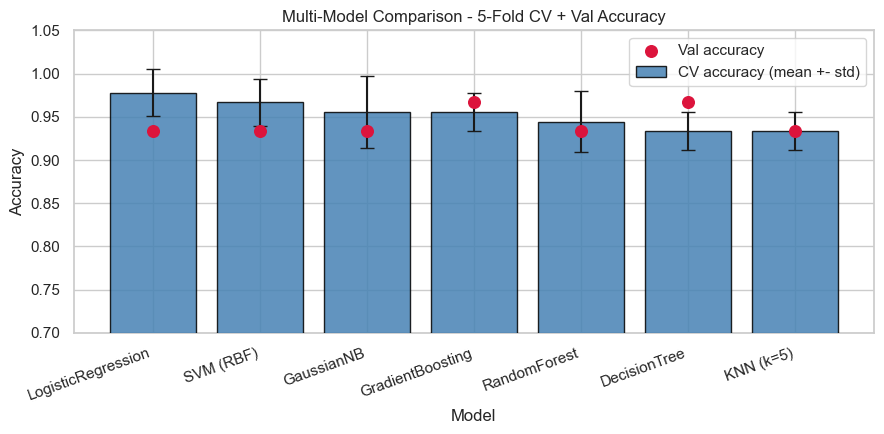

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(results_df))
ax.bar(x, results_df['CV Mean'], yerr=results_df['CV Std'],
       capsize=5, color='steelblue', edgecolor='black', alpha=0.85,
       zorder=3, label='CV accuracy (mean +- std)')
ax.scatter(x, results_df['Val Acc'], color='crimson', zorder=5, s=70, label='Val accuracy')
ax.set(xlabel='Model', ylabel='Accuracy', ylim=(0.7, 1.05),
       title='Multi-Model Comparison - 5-Fold CV + Val Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Hyperparameter Tuning + Final Test Evaluation

`GridSearchCV` exhaustively searches a parameter grid using CV. `refit=True` re-trains on all
of `X_train` with the best params after the search.

**Rules:**
- Tune hyperparameters using the training set (inside CV) only
- Evaluate the **final** model exactly **once** on the test set — do this at the very end

In [23]:
# clf__ prefix is required to pass params into the pipeline's 'clf' step
param_grid = {
    'clf__n_estimators':      [50, 100, 200],
    'clf__max_depth':         [None, 5, 10],
    'clf__min_samples_split': [2, 5],
}

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(random_state=42)),
])

grid_search = GridSearchCV(
    pipe_rf, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,    # use all CPU cores
    refit=True,   # re-train best config on all of X_train
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f'Best params:      {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_:.3f}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params:      {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV accuracy: 0.956


=== FINAL TEST SET EVALUATION - Tuned Random Forest ===
Accuracy: 0.967

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.91      1.00      0.95        10
 Iris-virginica       1.00      0.90      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



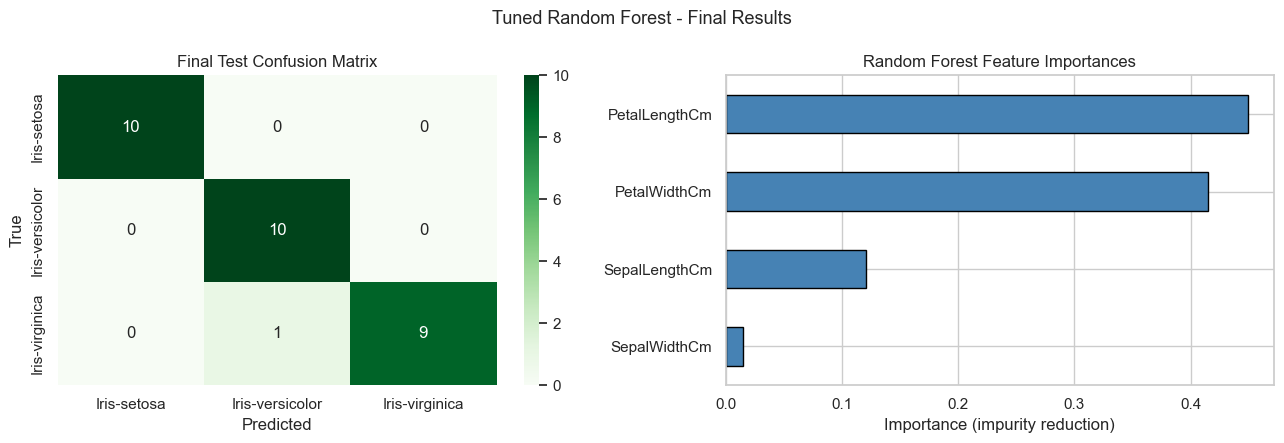

In [24]:
# FINAL: touch the test set exactly once
best_pipe = grid_search.best_estimator_
y_final   = best_pipe.predict(X_test)

print('=== FINAL TEST SET EVALUATION - Tuned Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, y_final):.3f}')
print()
print(classification_report(y_test, y_final, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

cm = confusion_matrix(y_test, y_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set(title='Final Test Confusion Matrix', xlabel='Predicted', ylabel='True')

rf_model = best_pipe.named_steps['clf']
feat_imp  = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black', ax=axes[1])
axes[1].set(title='Random Forest Feature Importances', xlabel='Importance (impurity reduction)')

plt.suptitle('Tuned Random Forest - Final Results', fontsize=13)
plt.tight_layout()
plt.show()